# COVID-19 Data Analysis
##  Objective
To analyze global COVID-19 trends, identify patterns in case growth, compare countries, and evaluate fatality rates to derive meaningful insights.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving owid-covid-data.csv to owid-covid-data.csv


# DATA LOADING

In [ ]:
df = pd.read_csv('owid-covid-data.csv')
df.head()


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,05-01-2020,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,06-01-2020,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,07-01-2020,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,08-01-2020,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,09-01-2020,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN


In [ ]:
df.columns


Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

# DATA UNDERSTANDING
## Data Understanding
The dataset contains country-wise COVID-19 data including total cases, deaths, and population.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

# DATA CLEANING
##  Data Cleaning
Handling missing values and preparing dataset for analysis.

In [ ]:
df = df[['location', 'date', 'total_cases', 'new_cases', 'total_deaths', 'new_deaths', 'population']]
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.dropna(subset=['total_cases', 'total_deaths'])
# Show cleaned data
df.head()


,location,date,total_cases,new_cases,total_deaths,new_deaths,population
0,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,41128772
1,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,41128772
2,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,41128772
3,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,41128772
4,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,41128772


# FEATURE ENGINEERING
##  Feature Engineering
Creating a new metric: fatality rate.

In [ ]:
df['fatality_rate'] = (df['total_deaths'] / df['total_cases']) * 100

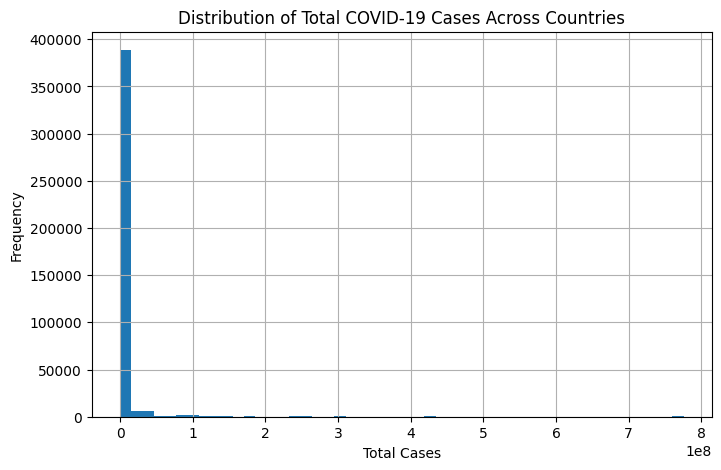

In [ ]:
plt.figure(figsize=(8,5))
df['total_cases'].hist(bins=50)
plt.title("Distribution of Total COVID-19 Cases Across Countries")
plt.xlabel("Total Cases")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# ANALYSIS 1 (TOP COUNTRIES)

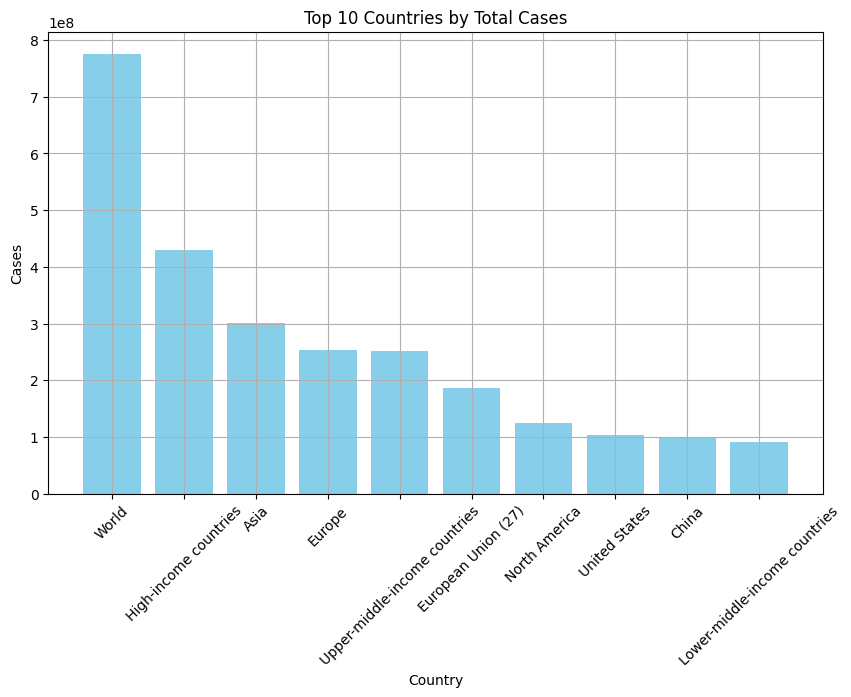

In [31]:
latest_data = df.sort_values(by=['location', 'date']).groupby('location').last().reset_index()

top10 = latest_data.sort_values(by='total_cases', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['location'], top10['total_cases'], color="skyblue")
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Total Cases")
plt.xlabel("Country")
plt.ylabel("Cases")
plt.grid(True)
plt.show()

Insight:
A small number of countries contribute significantly to total global cases, indicating uneven spread across regions.

# ANALYSIS 2 (INDIA TREND)


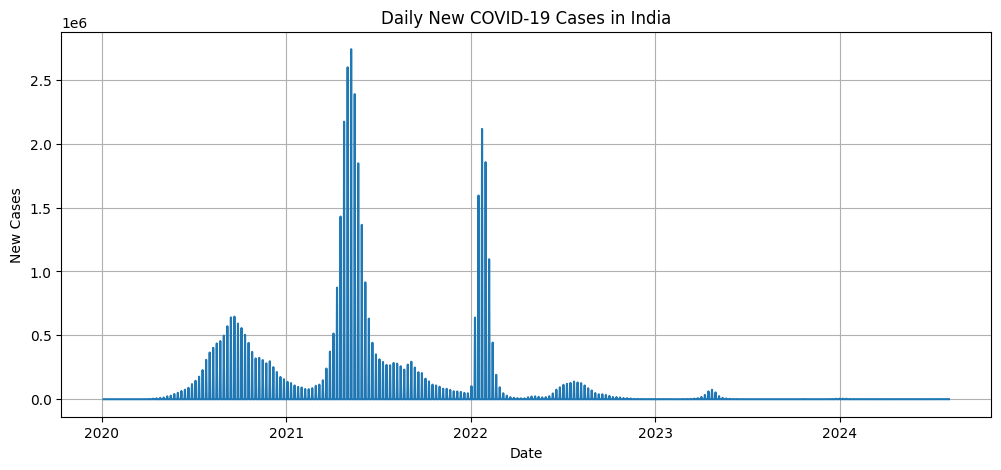

In [29]:
india = df[df['location'] == 'India'].sort_values('date')

plt.figure(figsize=(12,5))
plt.plot(india['date'], india['new_cases'], color="#1f77b4")
plt.title("Daily New COVID-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.grid(True)
plt.show()

Insight:
India shows multiple peaks in daily cases, reflecting different waves of the pandemic over time.

# ANALYSIS 3 (FATALITY RATE)

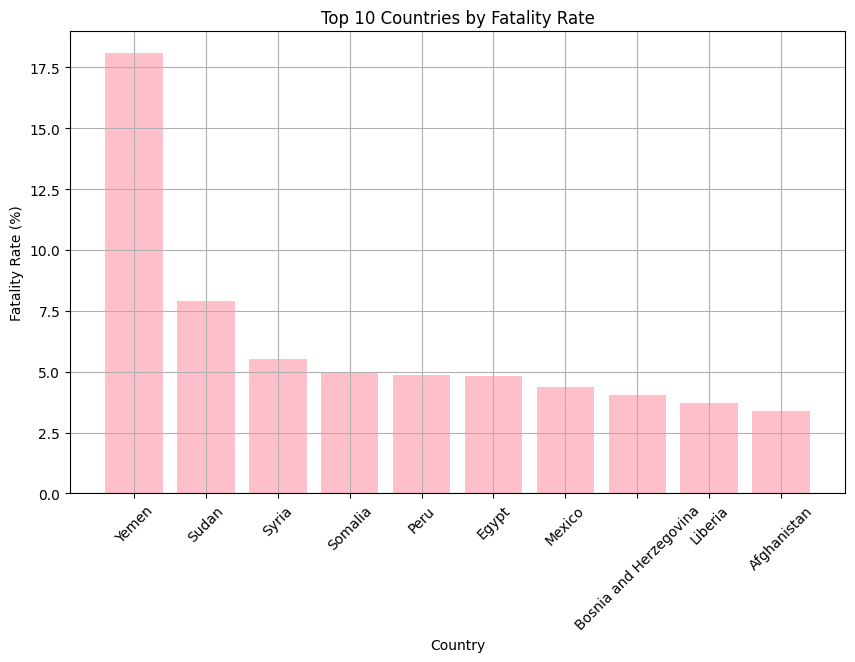

In [24]:
latest_data['fatality_rate'] = (
    latest_data['total_deaths'] / latest_data['total_cases']
) * 100

top10_cfr = latest_data.sort_values(by='fatality_rate', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_cfr['location'], top10_cfr['fatality_rate'], color='pink')
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Fatality Rate")
plt.xlabel("Country")
plt.ylabel("Fatality Rate (%)")
plt.grid(True)
plt.show()

Insight:
Higher fatality rates in certain countries may indicate healthcare limitations or differences in reporting.

In [39]:
from sklearn.linear_model import LinearRegression
import numpy as np

india = df[df['location'] == 'India'].sort_values('date')

# Smooth data
india['smoothed_cases'] = india['new_cases'].rolling(7).mean()
india = india.dropna()

# Use recent data only
india = india.tail(200)

# Convert date
india['date_ordinal'] = india['date'].map(pd.Timestamp.toordinal)

X = india[['date_ordinal']]
y = india['smoothed_cases']

In [40]:
# Train model
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [41]:
# Future prediction
future_days = 30
last_date = india['date'].max()

future_dates = [last_date + pd.Timedelta(days=i) for i in range(1, future_days+1)]
future_ordinal = [[d.toordinal()] for d in future_dates]

predictions = model.predict(future_ordinal)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


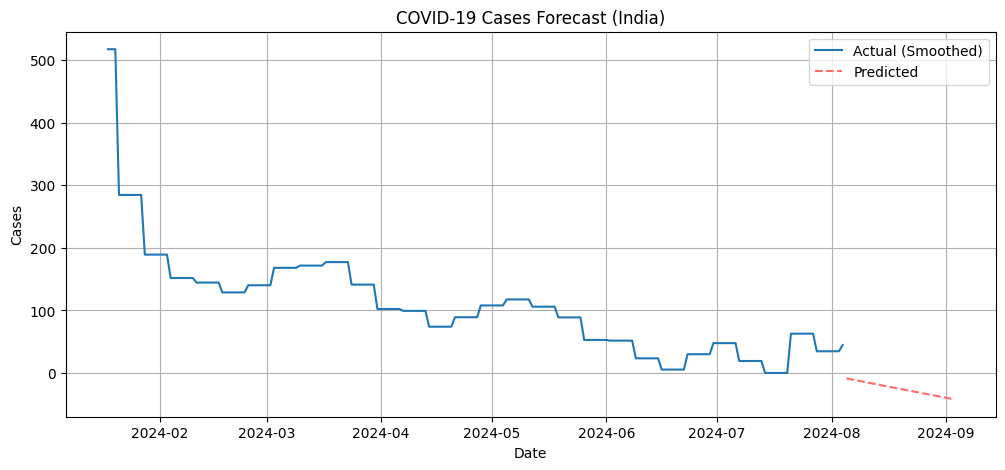

In [42]:
# Plot
plt.figure(figsize=(12,5))

plt.plot(india['date'], india['smoothed_cases'], label='Actual (Smoothed)', color='#1f77b4')
plt.plot(future_dates, predictions, label='Predicted', linestyle='--', color='#ff6b6b')

plt.title("COVID-19 Cases Forecast (India)")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.grid(True)
plt.show()

Insight:
A basic linear regression model was applied on smoothed data to understand short-term trends. However, COVID-19 patterns are highly non-linear and influenced by multiple external factors, so this model is used for trend indication rather than accurate forecasting.

## Final Insights

- COVID-19 spread followed multiple waves globally, indicating recurring outbreak cycles  
- Case trends across countries show similar patterns but differ in intensity  
- Fatality rates vary significantly, reflecting differences in healthcare systems and reporting  
- Data preprocessing plays a crucial role in ensuring accurate and meaningful analysis  

##  Conclusion
This project demonstrates the ability to clean, analyze, and interpret real-world data to generate actionable insights and support data-driven decision-making. It reflects an analytical approach to understanding large-scale data and deriving meaningful patterns from real-world datasets.

##  Future Scope
- Implement predictive modeling to forecast future case trends  
- Build interactive dashboard using Tableau or Power BI  

##  Skills Demonstrated
- Data Cleaning  
- Data Analysis  
- Data Visualization  
- Feature Engineering  
- Pandas & Matplotlib  

This project showcases the ability to work with real-world datasets and extract meaningful insights through structured data analysis.